# Лабораторная работа №3
### Набокова Алиса P3320 409211

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras import utils
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from string import punctuation
import re
import time
from tensorflow.keras.callbacks import EarlyStopping
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
tf.config.optimizer.set_jit(True)
tf.config.optimizer.set_experimental_options({"auto_mixed_precision": True})
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Без предобработки
def no_preprocess(text):
    return str(text)

# Минимальная: нижний регистр + удаление лишних пробелов
def minimal_preprocess(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Базовая: минимальная + удаление не-буквенных символов
def basic_preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Продвинутая: базовая + удаление стоп-слов + лемматизация
def advanced_preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

preprocess_functions = {
    'no_preprocess': no_preprocess,
    'minimal_preprocess': minimal_preprocess,
    'basic_preprocess': basic_preprocess,
    'advanced_preprocess': advanced_preprocess
}

In [ ]:
!wget -q https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/train.csv -O train.csv
!wget -q https://github.com/mhjabreel/CharCnn_Keras/raw/master/data/ag_news_csv/test.csv -O test.csv

train_data = pd.read_csv('train.csv', header=None, names=['class', 'title', 'text'])
test_data = pd.read_csv('test.csv', header=None, names=['class', 'title', 'text'])

#Имена колонок задаются вручную
train_texts = (train_data['title'] + ' ' + train_data['text']).values
test_texts = (test_data['title'] + ' ' + test_data['text']).values

#Использование заголовка и текста
y_train = utils.to_categorical(train_data['class'] - 1, 4)
y_test = utils.to_categorical(test_data['class'] - 1, 4)

print(f"Downloaded data: {len(train_data)} train, {len(test_data)} test")

Downloaded data: 120000 train, 7600 test


In [ ]:
VOCAB_SIZE = 6000
MAX_SEQ_LEN = 60

In [ ]:
def create_cnn_model():
    model = Sequential([
        layers.Embedding(VOCAB_SIZE + 1, 64),
        layers.Conv1D(32, 5, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.6),
        layers.Dense(4, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_lstm_model():
    model = Sequential([
        layers.Embedding(VOCAB_SIZE + 1, 64),
        layers.LSTM(32),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.6),
        layers.Dense(4, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def create_gru_model():
    model = Sequential([
        layers.Embedding(VOCAB_SIZE + 1, 64),
        layers.GRU(32),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.6),
        layers.Dense(4, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
experiment_results = {}
experiment_histories = {}
model_types = ['CNN', 'LSTM', 'GRU']
create_functions = {'CNN': create_cnn_model, 'LSTM': create_lstm_model, 'GRU': create_gru_model}

for prep_name, preprocess_func in preprocess_functions.items():
    print(f"\nЭксперимент с предобработкой: {prep_name}")
    print("-" * 50)

    start_time = time.time()

    train_processed = [preprocess_func(text) for text in train_texts]
    test_processed = [preprocess_func(text) for text in test_texts]

    vectorizer = TextVectorization(
        max_tokens=VOCAB_SIZE,
        output_mode='int',
        output_sequence_length=MAX_SEQ_LEN,
        standardize=None,
        split='whitespace'
    )
    vectorizer.adapt(train_processed)

    x_train = vectorizer(tf.constant(train_processed)).numpy()
    x_test = vectorizer(tf.constant(test_processed)).numpy()

    prep_time = time.time() - start_time
    print(f"Время предобработки: {prep_time:.2f} сек")

    for model_type in model_types:
        exp_key = f"{prep_name}_{model_type}"
        print(f"Обучаем {model_type}...")

        model = create_functions[model_type]()

        early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
        )

        history = model.fit(
            x_train, y_train,
            epochs=15,
            batch_size=256,
            validation_split=0.15,
            callbacks=[early_stopping],
            verbose=1
        )

        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

        experiment_results[exp_key] = {
            'test_acc': test_acc,
            'test_loss': test_loss,
            'prep_time': prep_time
        }
        experiment_histories[exp_key] = history


Эксперимент с предобработкой: no_preprocess
--------------------------------------------------
Время предобработки: 2.48 сек
Обучаем CNN...
Epoch 1/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5550 - loss: 1.0341 - val_accuracy: 0.8811 - val_loss: 0.3470
Epoch 2/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8720 - loss: 0.3986 - val_accuracy: 0.8862 - val_loss: 0.3187
Epoch 3/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8937 - loss: 0.3301 - val_accuracy: 0.8866 - val_loss: 0.3239
Epoch 4/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9097 - loss: 0.2806 - val_accuracy: 0.8863 - val_loss: 0.3400
Epoch 5/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9228 - loss: 0.2414 - val_accuracy: 0.8852 - val_loss: 0.3515
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Обучаем LSTM...
Epoch 1/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3029 - loss: 1.3214 - val_accuracy: 0.6329 - val_loss:

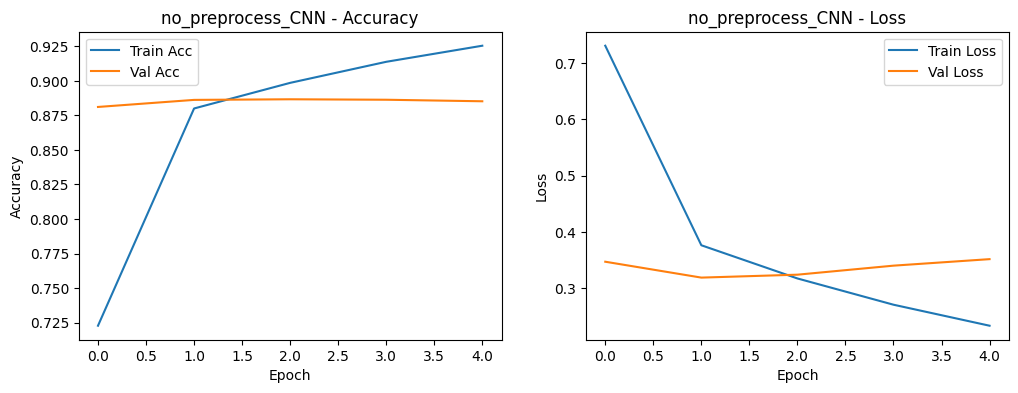

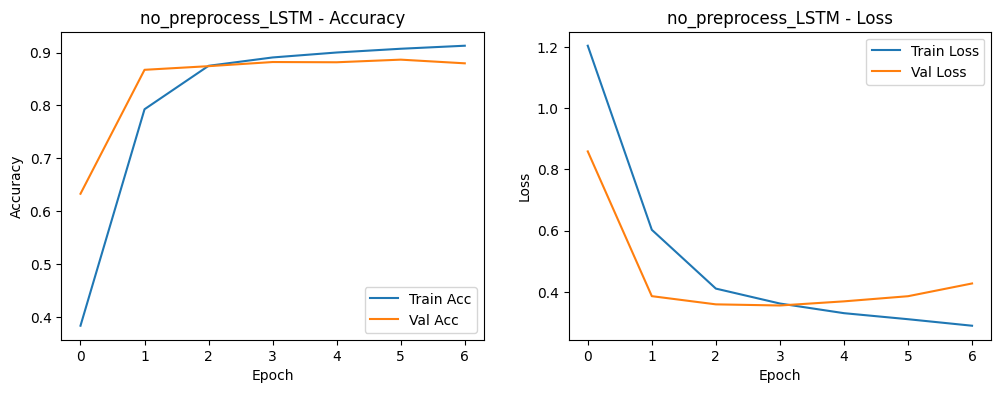

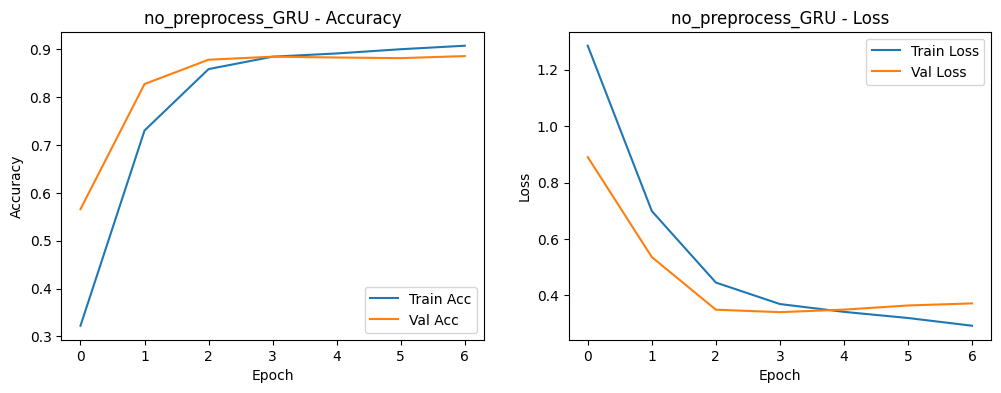

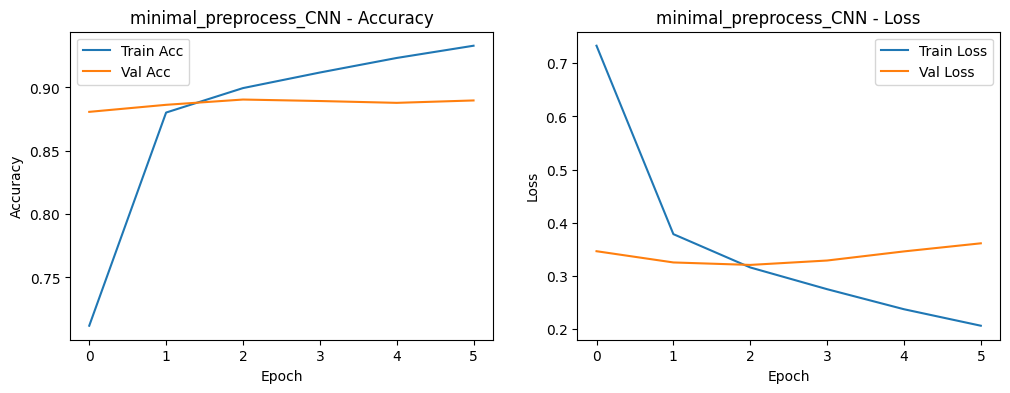

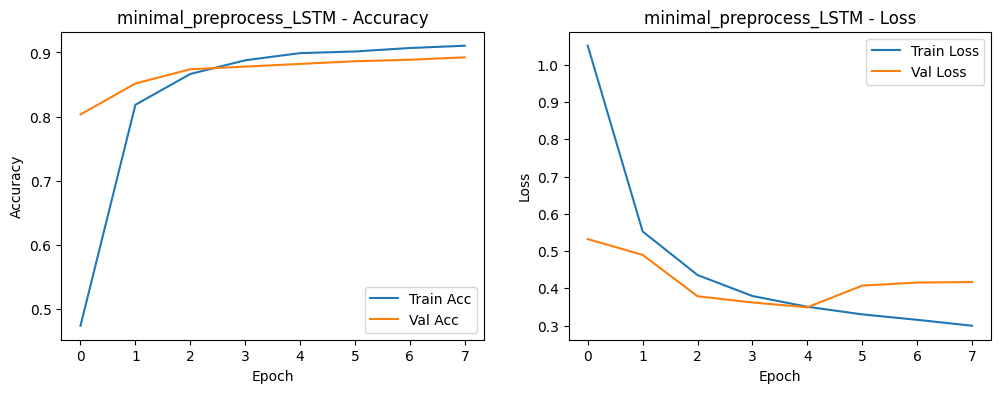

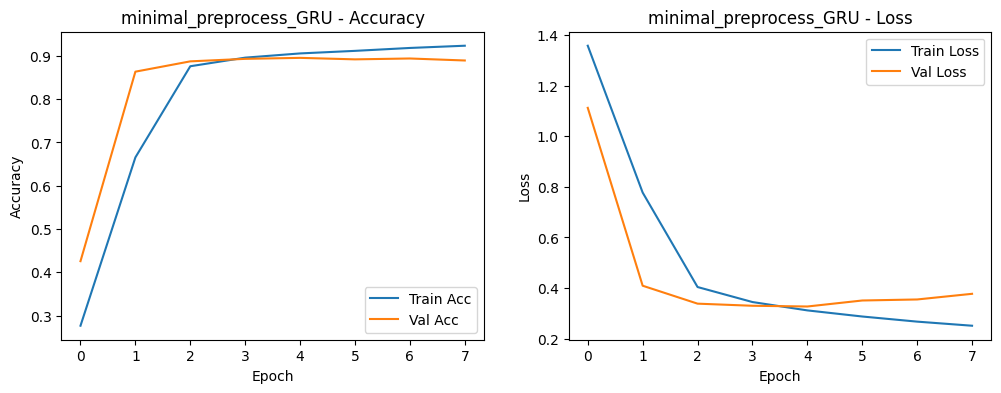

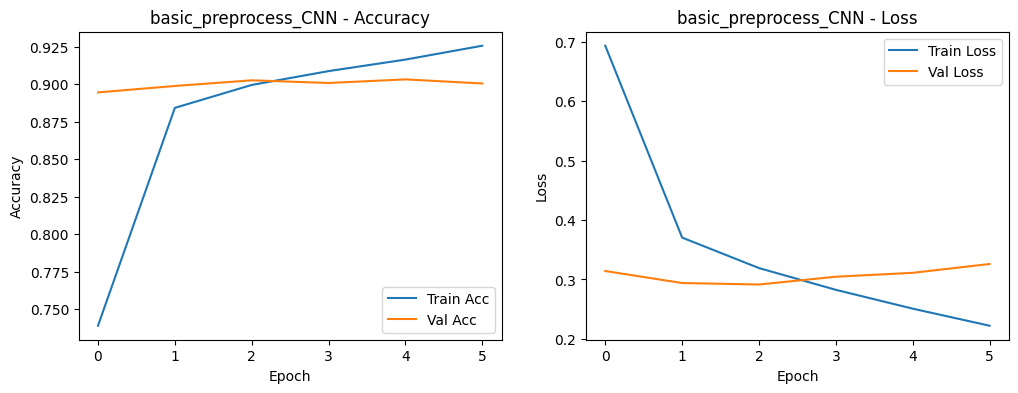

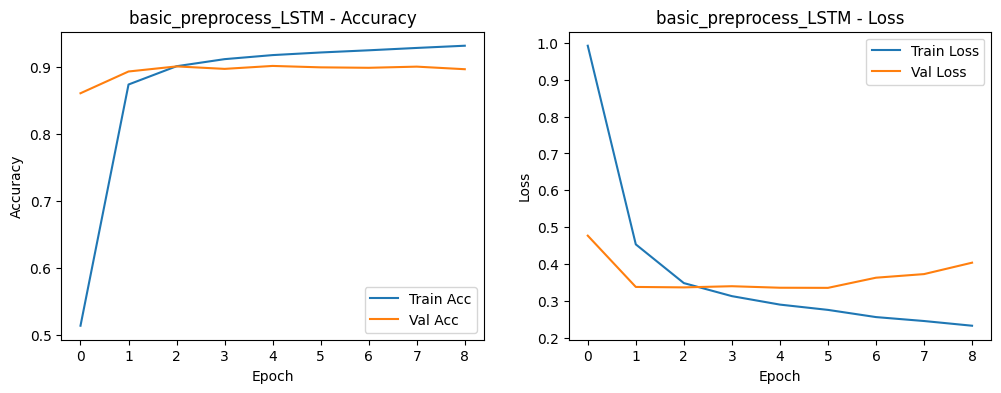

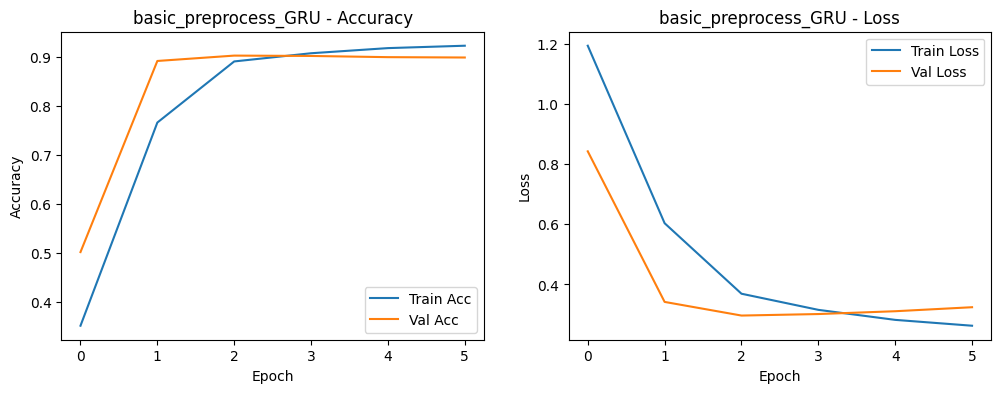

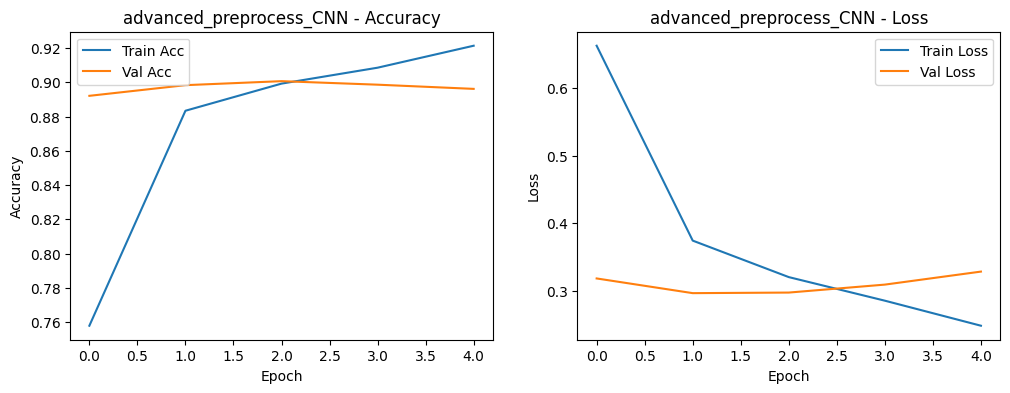

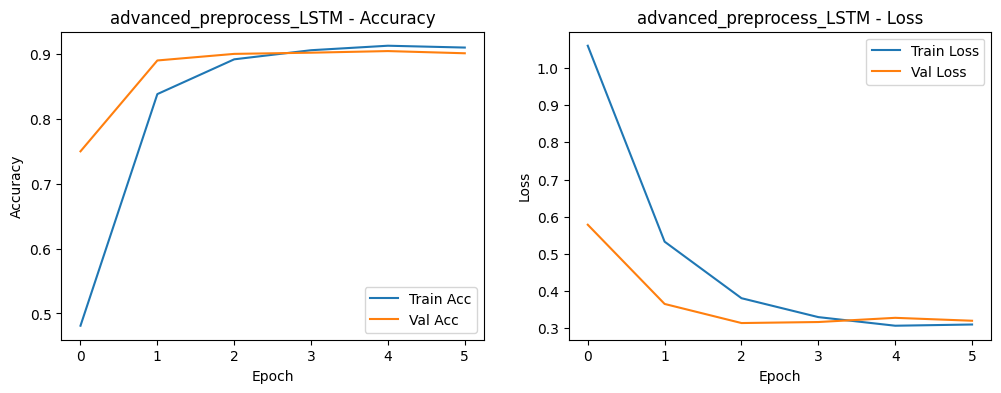

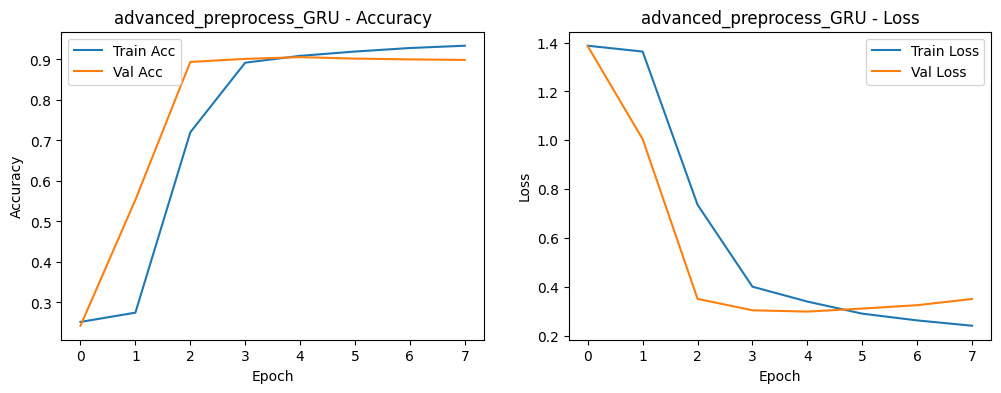

In [ ]:
for exp_key, history in experiment_histories.items():
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{exp_key} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{exp_key} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

#### Влияние предобработки

- Для CNN сложная предобработка почти не нужна
- Для RNN — LSTM/GRU — предобработка помогает быстрее обучаться и немного повышает точность

#### Гладкость
- CNN: обычно останавливались на 2–3 эпохе, точность стабилизирована
- LSTM/GRU: останавливались на 4–5 эпохе, сначала резкий рост, потом колебания

#### Общие выводы
CNN:
- Быстро обучается, высокая стабильная точность (~0.89–0.90)
- Предобработка почти не влияет

LSTM:
- Медленнее обучается, но достигает точности ~0.88–0.90
- Предобработка помогает слегка ускорить обучение

GRU:
- Лёгкая альтернатива LSTM
- Показатели почти такие же, но чуть быстрее